In [1]:
!pip install -U tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.1/612.1 kB 8.3 MB/s eta 0:00:00


In [2]:
#Loading libraries, we are using keras
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import scipy.io
import shutil
import torch

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:


# Path to images and annotations
path_images = "/101_ObjectCategories/airplanes/" # Defining folder structures of dataset, we are usign caltechs plane dataset
path_labels = "/Annotations/Airplanes_Side_2/" # Defining folder structure and path to labels

path_to_downloaded_file = keras.utils.get_file(
    fname="caltech_101_zipped",
    origin="https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip",
    extract=True,
    archive_format="zip",  # file formmat
    cache_dir="/",  # cache and extract in current directory
)

# Extracting  files found inside zip file
shutil.unpack_archive("/datasets/caltech-101/101_ObjectCategories.tar.gz", "/") # UNAPCK ZIP FILE
shutil.unpack_archive("/datasets/caltech-101/Annotations.tar", "/")

# list of paths to images and annotations
image_paths = [
    img for img in os.listdir(path_images) if os.path.isfile(os.path.join(path_images, img))
] #  Creating list containing path to images
label_paths = [
    cords for cords in os.listdir(path_labels) if os.path.isfile(os.path.join(path_labels,cords))
] #  Creating list containing path to labels which contains coordinates for bounding boxes

image_paths.sort() # Sorting the images according to name
label_paths.sort() # Sorting the labels according to name, ensuring same location of corresponding labels and images in  the arrays

image_size = 224  # resize input images to this size

images, targets = [], [] # empty lists

# loop over the annotations and images, preprocess them and store in lists
for i in range(len(image_paths)):
    # Access bounding box coordinates
    bounding_box_coords= scipy.io.loadmat(path_labels + label_paths[i])["box_coord"][0] # Loading labels, which are coordinates for box enclosing the objects detected

    top_left_x, top_left_y = bounding_box_coords[2], bounding_box_coords[0] # the arrangement of coordinates is accordingly, meaning the y coordinates comes first
    bottom_right_x, bottom_right_y = bounding_box_coords[3], bounding_box_coords[1]

    image = keras.utils.load_img(
        path_images + image_paths[i],
    ) # Loading corresponding images for the coordinate labels we just loaded
    (w, h) = image.size[:2]

    # resize train set images
    if i < int(len(image_paths) * 0.8):
        # resize image if it is for training dataset
        image = image.resize((image_size, image_size)) # Smaller images are easier to process as these are less computationally heavy and they need to be of the same size

    # convert image to array and append to list
    images.append(keras.utils.img_to_array(image))  # Keras and pytorch takes tensor as input but first we convert these images to arrays do som e preprocessing and then later convert to tensor when sent into network

    # apply scaling to bounding boxes, due to rezing of the images, and append these to a list
    targets.append(
        (
            float(top_left_x) / w,
            float(top_left_y) / h,
            float(bottom_right_x) / w,
            float(bottom_right_y) / h,
        )
    )

# Split to train and test datasets allocating 80%  to training /validation and 20% for test
(x_train), (y_train) = (
    np.asarray(images[: int(len(images) * 0.8)]),
    np.asarray(targets[: int(len(targets) * 0.8)]),
)
(x_test), (y_test) = (
    np.asarray(images[int(len(images) * 0.8) :]),
    np.asarray(targets[int(len(targets) * 0.8) :]),
)

137414764/137414764 [==============================] - 12s 0us/step


<ipython-input-3-b0ca7e54ee94>:69: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.asarray(images[int(len(images) * 0.8) :]),


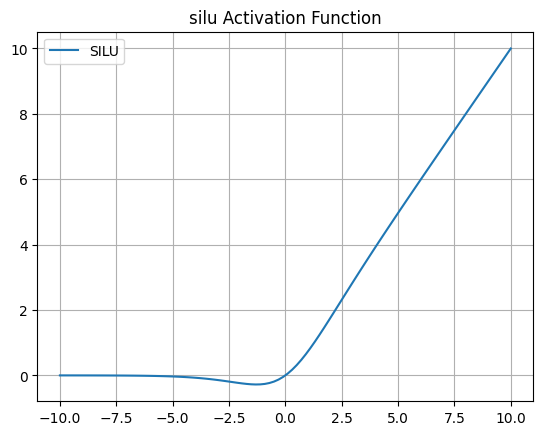

In [4]:
import torch
def mlp(x, hidden_units, dropout_rate=0.25): # dense layer calculate dot product
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.silu)(x) #silu is a very typical ativation function for
        x = layers.Dense(units, activation=tf.nn.silu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def silu(input):
    return input * torch.sigmoid(input)
# Generating data
x_data = np.linspace(-10,10,100)
y_data = silu(torch.tensor(x_data))


# Graph silu should we include derivative
plt.plot(x_data, y_data, )
plt.title('silu Activation Function')
plt.legend(['SILU'])
plt.grid()
plt.show()

In [5]:
'''
 def __init__(self) is a reseved method in python classes.
 It is known as a constructor in object oriented concepts.
  This method called when an object is created from the class and it allow
  the class to initialize the attributes of a class.
'''



class Patches(layers.Layer): # transformers gets multipl patches as input therefore we need to defines these as the dataset contain full images
    def __init__(self, patch_size):
        super().__init__() # Python, the super() function is used to refer to the parent class or superclass. It allows you to call methods defined in the superclass in other functions later
        self.patch_size = patch_size # saving

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        # return patches
        return tf.reshape(patches, [batch_size, -1, patches.shape[-1]])


Image size: 224 X 224
Patch size: 32 X 32
49 patches per image 
3072 elements per patch


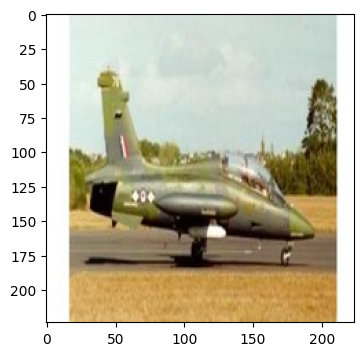

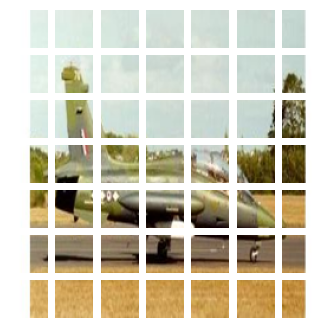

In [6]:
patch_size = 32  # Size of patches to be extracted from the input images

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0].astype("uint8"))


patches = Patches(patch_size)(tf.convert_to_tensor([x_train[0]])) # Creating patches of 32 x 32 of the training images and converting these to tensors. Kearas and pytorch takes tnesors as input
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"{patches.shape[1]} patches per image \n{patches.shape[-1]} elements per patch") # print patch shape

'''
Transformers handles images differently than a traditional cnns therefore we have to preprocess the images to be if tried to illustrate here
'''
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

In [7]:

class PatchEncoder(layers.Layer): #Encoding pathches using the same function as above where we create the patches  however with additonal variable declared as we need to do an encoding of our inputs for transformers this means we encode the patches relative to their position
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        ) # Transformer uses trans


    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1) # defining the popotion by using a numerical sequence in range 0-number of patches in the incrament delta delta where each is assigned
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


'''
The reason we use call() is that when tf.keras calls a model or a layer,
it has its own inner operations which are essential to keep its inner
structure. As a result, it exposes a method call() for custom overloading
'''


'\nThe reason we use call() is that when tf.keras calls a model or a layer,\nit has its own inner operations which are essential to keep its inner\nstructure. As a result, it exposes a method call() for custom overloading\n'

In [8]:
'''
def vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    inputs = layers.Input(shape=input_shape) # stadrad keras model
    # Create patches
    patches = Patches(patch_size)(inputs) # Create the input patches, using prevously defined function,  which transformers use as inputs
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches) # encode the patches relative to their postion

    # Create mulitple transformer blocks.
    for i in range(transformer_layers):
        # Layer normalization 1.
        #x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(encoded_patches, encoded_patches)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    bounding_box = layers.Dense(4)(
        features
    )  # Final four neurons that output bounding box

    # return Keras model.
    return keras.Model(inputs=inputs, outputs=bounding_box)
'''

'\ndef vit_object_detector(\n    input_shape,\n    patch_size,\n    num_patches,\n    projection_dim,\n    num_heads,\n    transformer_units,\n    transformer_layers,\n    mlp_head_units,\n):\n    inputs = layers.Input(shape=input_shape) # stadrad keras model\n    # Create patches\n    patches = Patches(patch_size)(inputs) # Create the input patches, using prevously defined function,  which transformers use as inputs\n    # Encode patches\n    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches) # encode the patches relative to their postion\n\n    # Create mulitple transformer blocks.\n    for i in range(transformer_layers):\n        # Layer normalization 1.\n        #x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)\n        # Create a multi-head attention layer.\n        attention_output = layers.MultiHeadAttention(\n            num_heads=num_heads, key_dim=projection_dim, dropout=0.1\n        )(encoded_patches, encoded_patches)\n        # Skip connection

In [9]:
# second way of defining
def vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    inputs = layers.Input(shape=input_shape) # stadrad keras model
    # Create patches
    patches = Patches(patch_size)(inputs) # Create the input patches, using prevously defined function,  which transformers use as inputs
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches) # encode the patches relative to their postion
    attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(encoded_patches, encoded_patches)
        # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x4 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
    x4 = layers.Add()([x4, x2])
    #Block 2
    attention_output_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x4, x4)
        # Skip connection 1.
    x5 = layers.Add()([attention_output_1, x4])
        # Layer normalization 2.
    x6 = layers.LayerNormalization(epsilon=1e-6)(x5)
        # MLP
    x7 = mlp(x6, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
    x7 = layers.Add()([x7, x5])

    attention_output_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x7, x7)
        # Skip connection 1.
    x8 = layers.Add()([attention_output_2, x7])
        # Layer normalization 2.
    x9 = layers.LayerNormalization(epsilon=1e-6)(x8)
        # MLP
    x9 = mlp(x9, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
    x10 = layers.Add()([x9, x8])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(x10)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    bounding_box = layers.Dense(4)(
        features
    )  # Final four neurons that output bounding box

    # return Keras model.
    return keras.Model(inputs=inputs, outputs=bounding_box)


In [10]:

def run_experiment(model, learning_rate, weight_decay, batch_size, num_epochs):

    optimizer = tfa.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    # Compile model.
    model.compile(optimizer=optimizer, loss=keras.losses.MeanSquaredError())
    model.summary()

    checkpoint_filepath = "logs/"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[
            checkpoint_callback,
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=10),
        ],
    )

    return history


input_shape = (image_size, image_size, 3)  # input image shape
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 32
num_epochs = 100
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
# Size of the transformer layers
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 4
mlp_head_units = [2048, 1024, 512, 64, 32]  # Size of the dense layers


history = []
num_patches = (image_size // patch_size) ** 2

object_detection = vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
)

# Train model
history = run_experiment(
    object_detection, learning_rate, weight_decay, batch_size, num_epochs
)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 patches_1 (Patches)         (None, None, 3072)           0         ['input_1[0][0]']             
                                                                                                  
 patch_encoder (PatchEncode  (None, 49, 64)               199808    ['patches_1[0][0]']           
 r)                                                                                               
                                                                                                  
 multi_head_attention (Mult  (None, 49, 64)               66368     ['patch_encoder[0][0]',   

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 1s 592ms/step
corodinates of  detected object:  [0.12313658 0.19189855 0.82023907 0.76060796]
1/1 [==============================] - 0s 22ms/step
corodinates of  detected object:  [0.12293194 0.19175026 0.8207115  0.76085854]
1/1 [==============================] - 0s 24ms/step
corodinates of  detected object:  [0.12294199 0.19177309 0.8206644  0.76083094]
1/1 [==============================] - 0s 24ms/step
corodinates of  detected object:  [0.12309365 0.19187081 0.82033026 0.7606596 ]
1/1 [==============================] - 0s 23ms/step
corodinates of  detected object:  [0.1230005  0.19178486 0.8205545  0.7607562 ]
1/1 [==============================] - 0s 30ms/step
corodinates of  detected object:  [0.12321766 0.19195262 0.82008207 0.7605369 ]
1/1 [==============================] - 0s 24ms/step
corodinates of  detected object:  [0.12333617 0.19207785 0.8198129  0.7604188 ]
1/1 [==============================] - 0s 23ms/step
corodinates of  detecte

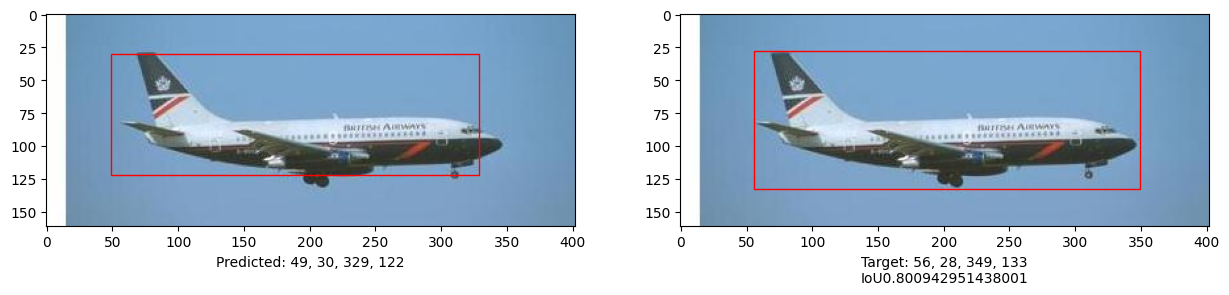

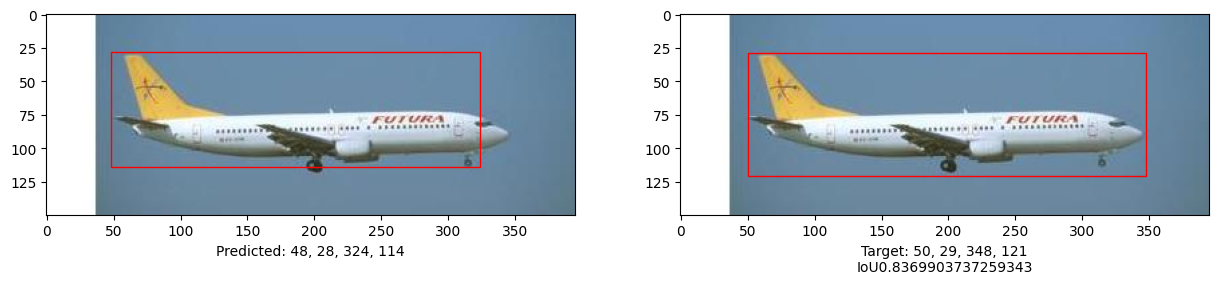

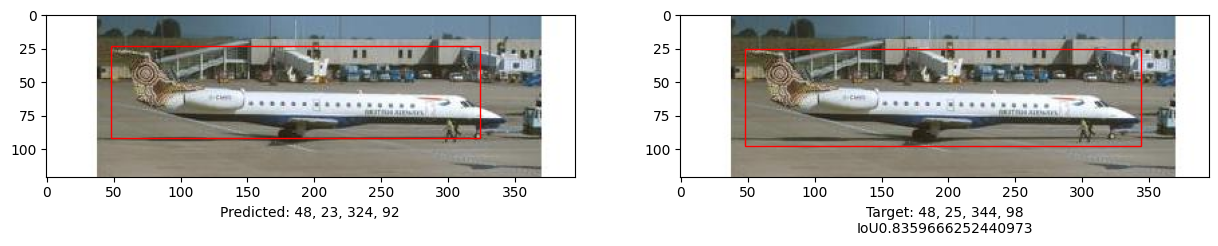

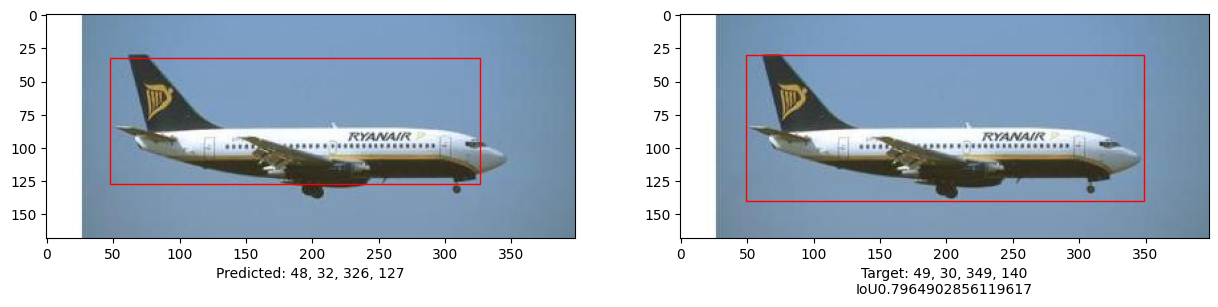

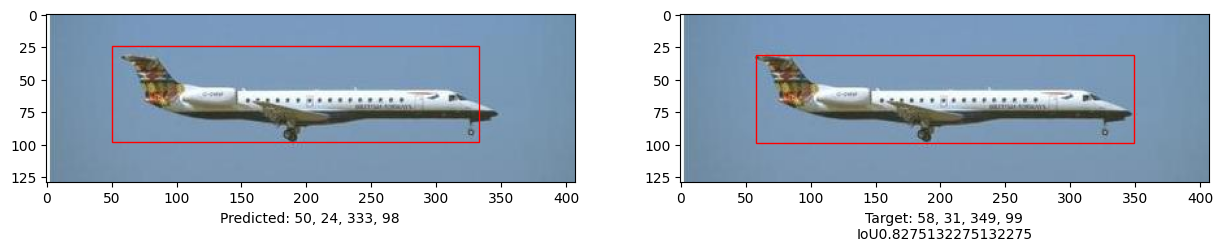

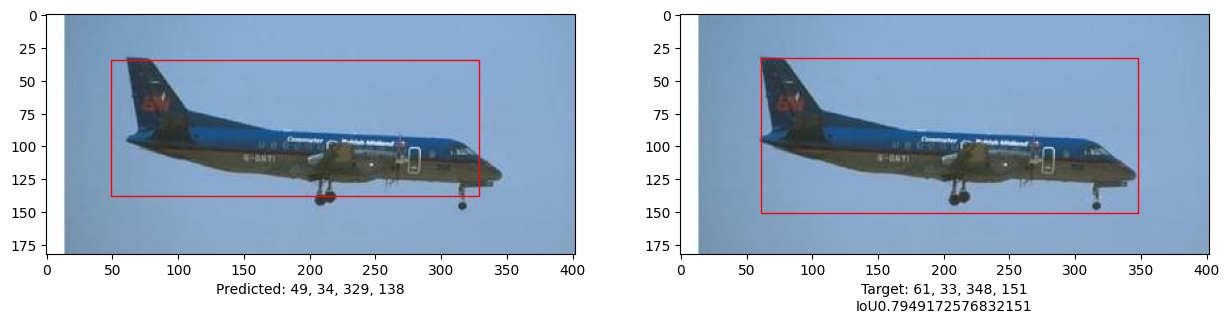

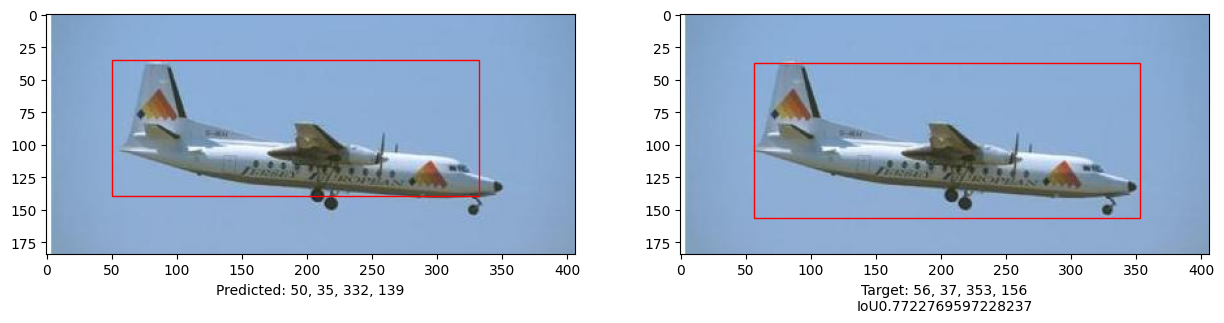

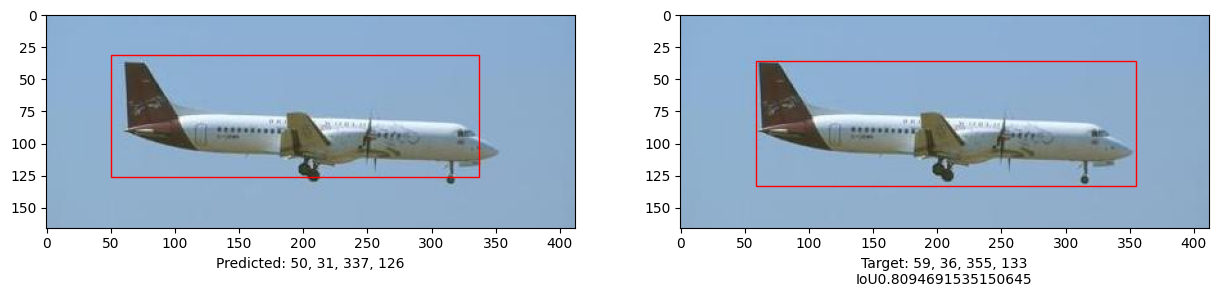

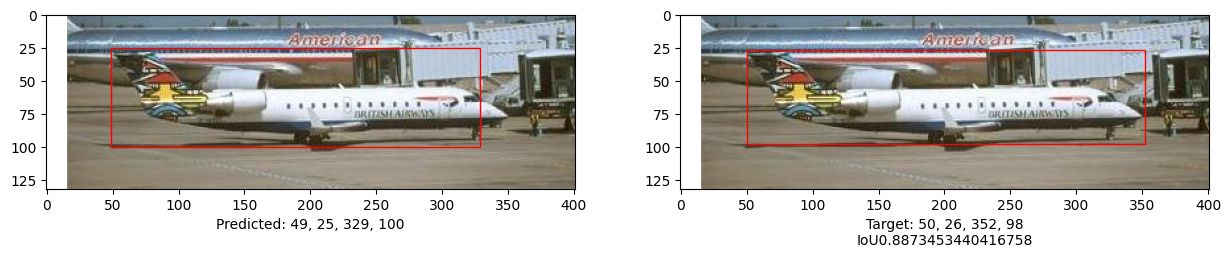

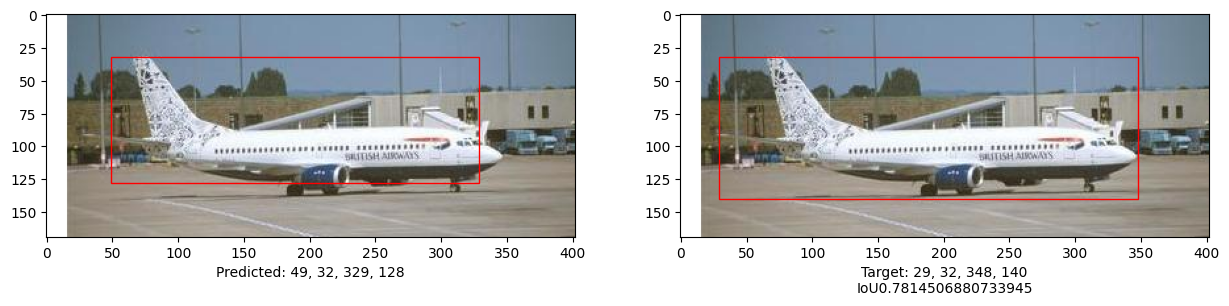

In [11]:
import matplotlib.patches as patches

# Saves the model in current path
object_detection.save("vit_object_detector.h5", save_format="h5")

# To calculate IoU (intersection over union, given two bounding boxes)
def bounding_box_intersection_over_union(box_predicted, box_truth):
    # get (x, y) coordinates of intersection of bounding boxes
    top_x_intersect = max(box_predicted[0], box_truth[0])
    top_y_intersect = max(box_predicted[1], box_truth[1])
    bottom_x_intersect = min(box_predicted[2], box_truth[2])
    bottom_y_intersect = min(box_predicted[3], box_truth[3])

    # calculate area of the intersection bb (bounding box)
    intersection_area = max(0, bottom_x_intersect - top_x_intersect + 1) * max(
        0, bottom_y_intersect - top_y_intersect + 1
    )

    # calculate area of the prediction bb and ground-truth bb
    box_predicted_area = (box_predicted[2] - box_predicted[0] + 1) * (
        box_predicted[3] - box_predicted[1] + 1
    )
    box_truth_area = (box_truth[2] - box_truth[0] + 1) * (
        box_truth[3] - box_truth[1] + 1
    )

    # calculate intersection over union by taking intersection
    # area and dividing it by the sum of predicted bb and ground truth
    # bb areas subtracted by  the interesection area

    # return ioU
    return intersection_area / float(
        box_predicted_area + box_truth_area - intersection_area
    )


i, mean_iou = 0, 0

# Compare results for 10 images in the test set
for input_image in x_test[:10]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
    im = input_image

    # Display the image
    ax1.imshow(im.astype("uint8"))
    ax2.imshow(im.astype("uint8"))

    input_image = cv2.resize(
        input_image, (image_size, image_size), interpolation=cv2.INTER_AREA
    )
    input_image = np.expand_dims(input_image, axis=0)
    preds = object_detection.predict(input_image)[0]
    print("corodinates of  detected object: ", preds)

    (h, w) = (im).shape[0:2]

    top_left_x, top_left_y = int(preds[0] * w), int(preds[1] * h)

    bottom_right_x, bottom_right_y = int(preds[2] * w), int(preds[3] * h)

    box_predicted = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]
    # Create the bounding box
    bounding_box = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax1.add_patch(bounding_box)
    ax1.set_xlabel(
        "Predicted: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
    )

    top_left_x, top_left_y = int(y_test[i][0] * w), int(y_test[i][1] * h)

    bottom_right_x, bottom_right_y = int(y_test[i][2] * w), int(y_test[i][3] * h)

    box_truth = top_left_x, top_left_y, bottom_right_x, bottom_right_y

    mean_iou += bounding_box_intersection_over_union(box_predicted, box_truth)
    # Create the bounding box
    bounding_box = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax2.add_patch(bounding_box)
    ax2.set_xlabel(
        "Target: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
        + "\n"
        + "IoU"
        + str(bounding_box_intersection_over_union(box_predicted, box_truth))
    )
    i = i + 1

print("mean_iou: " + str(mean_iou / len(x_test[:10])))
plt.show()